In [1]:
import os
import glob
import gc
import random

import numpy as np
import pandas as pd

from scipy.stats import median_abs_deviation, percentileofscore

import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc

import pegasus as pg
from pegasusio import UnimodalData, MultimodalData

from tqdm import tqdm

%matplotlib inline

sc.settings.n_jobs = 25

random.seed(0)
np.random.seed(0)
sc.settings.seed = 0

In [2]:
## From Cellbender Import ##

fernando_adata = sc.read_h5ad('/mnt/sdb/scz_meta_analysis_processed/fernando_brennand/anndata_objs/fernando_cellbendered.h5ad')

fernando_adata.obs['Run'] = [i.split('_')[0] for i in fernando_adata.obs_names]

fernando_adata.obs['barcodes'] = fernando_adata.obs_names

# filter ambient rna
fernando_adata = fernando_adata[fernando_adata.obs['cell']].copy()

In [3]:
## Cells After Ambient RNA Removal ##

fernando_adata.shape[0]

465228

In [4]:
## Merge SRA Metadata ##

fernando_sra_metadata = pd.read_csv('/mnt/lacie/scz_meta_analysis/fernando_brennand_nature_2025/metadata/Fernando_SRA_RunTable.csv')

fernando_sra_metadata_essential = fernando_sra_metadata[['Run', 'BioProject', 'BioSample', 'cell_line', 'cell_type', 
                                                         'Center Name', 'Experiment', 'genotype',
                                                         'Instrument', 'Library Name', 'ReleaseDate', 'create_date', 'Sample Name', 
                                                         'SRA Study', 'time']]

fernando_sra_metadata_essential.rename({'cell_line':'Donor'}, axis=1, inplace=True)

fernando_adata.obs = fernando_adata.obs.merge(fernando_sra_metadata_essential, left_on='Run', right_on='Run', how='left')

fernando_adata.obs.index = fernando_adata.obs['barcodes']

/tmp/ipykernel_96209/2934047644.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fernando_sra_metadata_essential.rename({'cell_line':'Donor'}, axis=1, inplace=True)


In [5]:
## Map NCBI Gene Names w/Prasanth's File ##

# load prasanth's annotation file
prasanth_annot = pd.read_csv('/home/deepak/datasets/annotations/all_genes_EnsemblInfo_104.csv')

# merge prasanth's gene info into the var dataframe
fernando_adata.var['ensembl_gene_id'] = fernando_adata.var.index
#del notaras_adata.var['gene_name']
fernando_adata.var = fernando_adata.var.merge(prasanth_annot, left_on='ensembl_gene_id', right_on='ensembl_gene_id', how='left')
fernando_adata.var.chromosome_name = fernando_adata.var.chromosome_name.astype('str')

# fix gene name that is NaN
fernando_adata.var.loc[fernando_adata.var['hgnc_symbol'].isna(),'hgnc_symbol'] = fernando_adata.var.loc[fernando_adata.var['hgnc_symbol'].isna(),'ensembl_gene_id']

#reset the index as the hgnc_symbol
fernando_adata.var.index = fernando_adata.var['hgnc_symbol']
fernando_adata.var.index.name = None

#some ensembls map to same hgnc so we make them unique
fernando_adata.var_names_make_unique(join='#')

gc.collect()

/tmp/ipykernel_96209/196425701.py:4: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  prasanth_annot = pd.read_csv('/home/deepak/datasets/annotations/all_genes_EnsemblInfo_104.csv')


66195

In [6]:
## Donor Metadata From Supplementary Table 2 of Paper ##

fernando_donor_metadata = pd.read_csv('/mnt/lacie/scz_meta_analysis/fernando_brennand_nature_2025/metadata/Fernando_Supplementary_Table_1.csv')

fernando_adata.obs = fernando_adata.obs.merge(fernando_donor_metadata, 
                                            left_on='Donor', 
                                            right_on='Patient ID', how='left').set_index('barcodes')

fernando_adata.obs['Sex'] = fernando_adata.obs['Sex'].astype('str')

In [7]:
## Remove Duplicate Barcodes ##

print(fernando_adata.obs_names.duplicated(keep=False).any())
print(fernando_adata.var_names.duplicated(keep=False).any())

# None

False
False


In [8]:
## Set Up QC Metrics ##

# filter on robust genes
# annotate_robust_genes_scanpy(integrated, percent_cells=0.05)
pg.identify_robust_genes(fernando_adata, percent_cells=0.05)
fernando_adata = fernando_adata[:,fernando_adata.var['robust']].copy()
gc.collect()

# mitochondrial genes, "MT-" for human, "Mt-" for mouse
fernando_adata.var["mt"] = fernando_adata.var_names.str.startswith("MT-")
# ribosomal genes
fernando_adata.var["ribo"] = fernando_adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
fernando_adata.var["hb"] = fernando_adata.var_names.str.contains("^HB[^(P)]")

# add protein_coding genes
fernando_adata.var['protein_coding'] = fernando_adata.var['gene_biotype'].apply(lambda x: True if 'protein_coding' == x else False)
fernando_adata.var['protein_coding'] = fernando_adata.var['protein_coding'].astype('bool')

# define mitocarta_genes
mitocarta_df = pd.read_csv('/home/deepak/datasets/annotations/Human.MitoCarta3.0.csv')
fernando_adata.var['mitocarta'] = [True if x in list(mitocarta_df['Symbol']) else False for x in fernando_adata.var.index]

# define robust_protein_coding genes (exclude ribosomal (RPL,RPS), mitochondrial, or mitocarta genes
fernando_adata.var['robust_protein_coding'] = fernando_adata.var['robust'] & fernando_adata.var['protein_coding']
fernando_adata.var.loc[fernando_adata.var.ribo, 'robust_protein_coding'] = False
fernando_adata.var.loc[fernando_adata.var.mt, 'robust_protein_coding'] = False
fernando_adata.var.loc[fernando_adata.var.mitocarta, 'robust_protein_coding'] = False

# define robust_protein_coding_autosome genes (exclude ribosomal (RPL,RPS), mitochondrial, or mitocarta genes
fernando_adata.var['autosome'] = fernando_adata.var.chromosome_name.isin([str(i) for i in range(1,23)])
fernando_adata.var['robust_protein_coding_autosome'] = fernando_adata.var['robust_protein_coding'] & fernando_adata.var['autosome'] 

2026-02-22 22:49:45,509 - pegasus.tools.preprocessing - INFO - After filtration, 30077/33538 genes are kept. Among 30077 genes, 18828 genes are robust.
2026-02-22 22:49:45,510 - pegasus.tools.preprocessing - INFO - Function 'identify_robust_genes' finished in 3.89s.


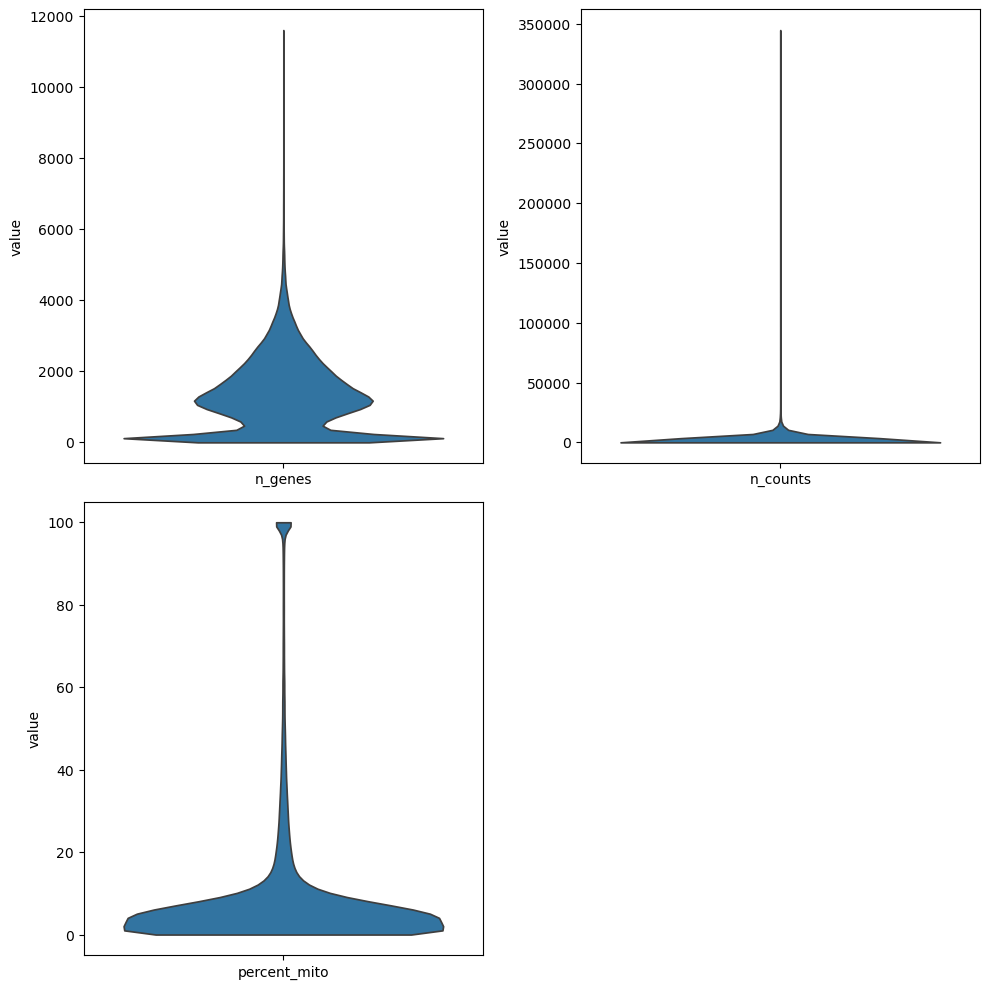

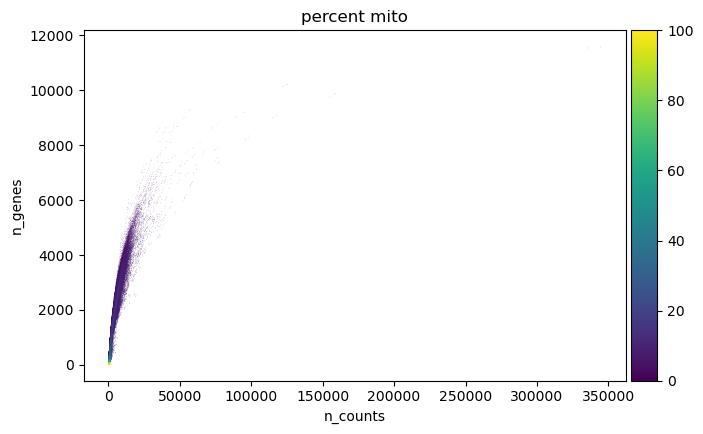

The 99th percentile all sample genes/cell is: 3218.0
The 99th percentile all sample total counts/cell is: 8872.649999999965
The 99th percentile all sample mitochondrial % /cell is: 35.8974358974359


In [9]:
## Plot QC Metrics ##

# QC by counts #
# convert to pegasus unimodal object
fernando_adata = UnimodalData(fernando_adata)
pg.qc_metrics(fernando_adata, mito_prefix='MT-')

# Create a figure with 3 subplots

# convert back for plotting to scanpy anndata
fernando_adata = fernando_adata.to_anndata()
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()
sc.pl.violin(fernando_adata, "n_genes", ax=axes[0], show=False, stripplot=False)
sc.pl.violin(fernando_adata, "n_counts", ax=axes[1], show=False, stripplot=False)
sc.pl.violin(fernando_adata, "percent_mito", ax=axes[2], show=False, stripplot=False)
fig.delaxes(axes[3])
plt.tight_layout()

sc.pl.scatter(fernando_adata, "n_counts", "n_genes", color="percent_mito")

print('The 99th percentile all sample genes/cell is: {0}'.format(np.percentile(fernando_adata.obs['n_genes'], 95)))

print('The 99th percentile all sample total counts/cell is: {0}'.format(np.percentile(fernando_adata.obs['n_counts'], 95)))

print('The 99th percentile all sample mitochondrial % /cell is: {0}'.format(np.percentile(fernando_adata.obs['percent_mito'], 95)))

n_UMIs lower: 262 upper: 18831
n_genes lower: 228 upper: 6448


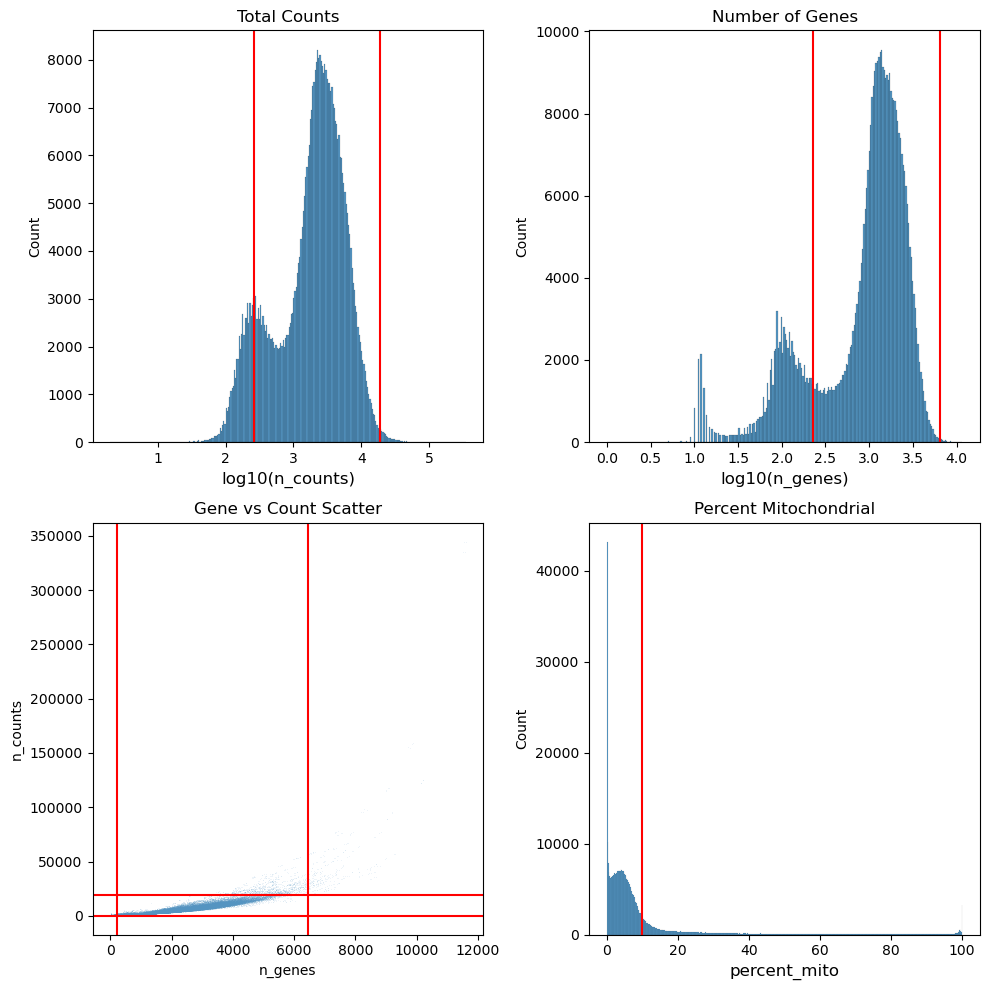

In [10]:
## Visualizating QC Cutoffs ##

MAD = 3

def qc_boundary(counts, k=MAD):
    x = np.log1p(counts)
    mad = median_abs_deviation(x)
    return np.exp(np.median(x) - k*mad), np.exp(np.median(x) + k*mad)

### nUMI and nGene QCs
n_counts_lower, n_counts_upper = qc_boundary(fernando_adata.obs.n_counts, k=MAD)
print('n_UMIs lower: %d upper: %d' % (n_counts_lower, n_counts_upper))

n_genes_lower, n_genes_upper = qc_boundary(fernando_adata.obs.n_genes, k=MAD)
print('n_genes lower: %d upper: %d' % (n_genes_lower, n_genes_upper))

## Plot Changes to Counts and Genes/Cell Distributions ##

fig, axs = plt.subplots(2, 2, figsize=(10, 10))  # 2x2 grid, adjust size as needed

# Plot 1: log10(n_counts)
sns.histplot(np.log10(fernando_adata.obs.n_counts), ax=axs[0, 0])
axs[0, 0].axvline(np.log10(n_counts_lower), color='red')
axs[0, 0].axvline(np.log10(n_counts_upper), color='red')
axs[0, 0].set_xlabel('log10(n_counts)', fontsize=12)
axs[0, 0].set_title("Total Counts")

# Plot 2: log10(n_genes)
sns.histplot(np.log10(fernando_adata.obs.n_genes), ax=axs[0, 1])
axs[0, 1].axvline(np.log10(n_genes_lower), color='red')
axs[0, 1].axvline(np.log10(n_genes_upper), color='red')
axs[0, 1].set_xlabel('log10(n_genes)', fontsize=12)
axs[0, 1].set_title("Number of Genes")

# Plot 3: scatter plot of n_genes vs n_counts
sns.scatterplot(x=fernando_adata.obs.n_genes, y=fernando_adata.obs.n_counts, alpha=0.5, s=0.1, ax=axs[1, 0])
axs[1, 0].axhline(n_counts_lower, color='red')
axs[1, 0].axhline(n_counts_upper, color='red')
axs[1, 0].axvline(n_genes_lower, color='red')
axs[1, 0].axvline(n_genes_upper, color='red')
axs[1, 0].set_xlabel('n_genes')
axs[1, 0].set_ylabel('n_counts')
axs[1, 0].set_title("Gene vs Count Scatter")

# Plot 4: percent_mito
sns.histplot(fernando_adata.obs.percent_mito, ax=axs[1, 1])
axs[1, 1].axvline(10, color='red')
axs[1, 1].set_xlabel('percent_mito', fontsize=12)
axs[1, 1].set_title("Percent Mitochondrial")

plt.tight_layout()
plt.show()

n_cells before QC: 465228
n_cells after QC: 465228
mean n_cells before QC 11630.7
mean n_cells after QC 11630.7


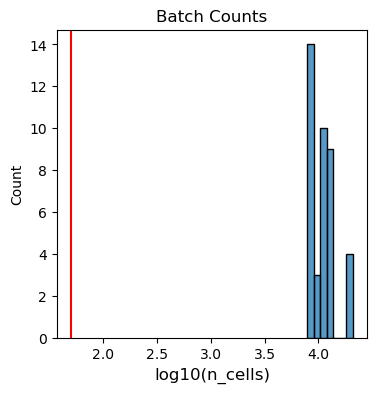

remove 0 batches that have cells less than 50


In [11]:
## Minimum Cell Cutoffs Based on Donor-Batches ##

args_min_n_cells = 50

n_cells_before_qc = fernando_adata.obs.library.value_counts().rename_axis('library').reset_index(name='counts')
n_cells_after_qc = fernando_adata.obs[fernando_adata.obs.passed_qc].library.value_counts().rename_axis('library').reset_index(name='counts')

print('n_cells before QC:', np.sum(n_cells_before_qc[n_cells_before_qc.counts>0].counts))
print('n_cells after QC:', np.sum(n_cells_after_qc[n_cells_after_qc.counts>0].counts))

print('mean n_cells before QC', np.mean(n_cells_before_qc[n_cells_before_qc.counts>0].counts))
print('mean n_cells after QC', np.mean(n_cells_after_qc[n_cells_after_qc.counts>0].counts))

# Plot Distribution of Donor-Batches on Being Greater than Zero
plt.figure(figsize=(4, 4))
plt.title('Batch Counts')
sns.histplot(np.log10(n_cells_before_qc[n_cells_before_qc.counts>0].counts))
plt.axvline(np.log10(args_min_n_cells), color='red')
plt.xlabel('log10(n_cells)', fontsize=12)
plt.show()

### n_cells QC

#identify donor-batches with less than 50 cells of contribution
n_cells_outlier = list(n_cells_after_qc[n_cells_after_qc.counts<args_min_n_cells].library)
# set these to have failed QC as well
fernando_adata.obs.loc[fernando_adata.obs.library.isin(n_cells_outlier),'passed_qc'] = False
print('remove {0} batches that have cells less than {1}'.format(len(n_cells_outlier), args_min_n_cells))

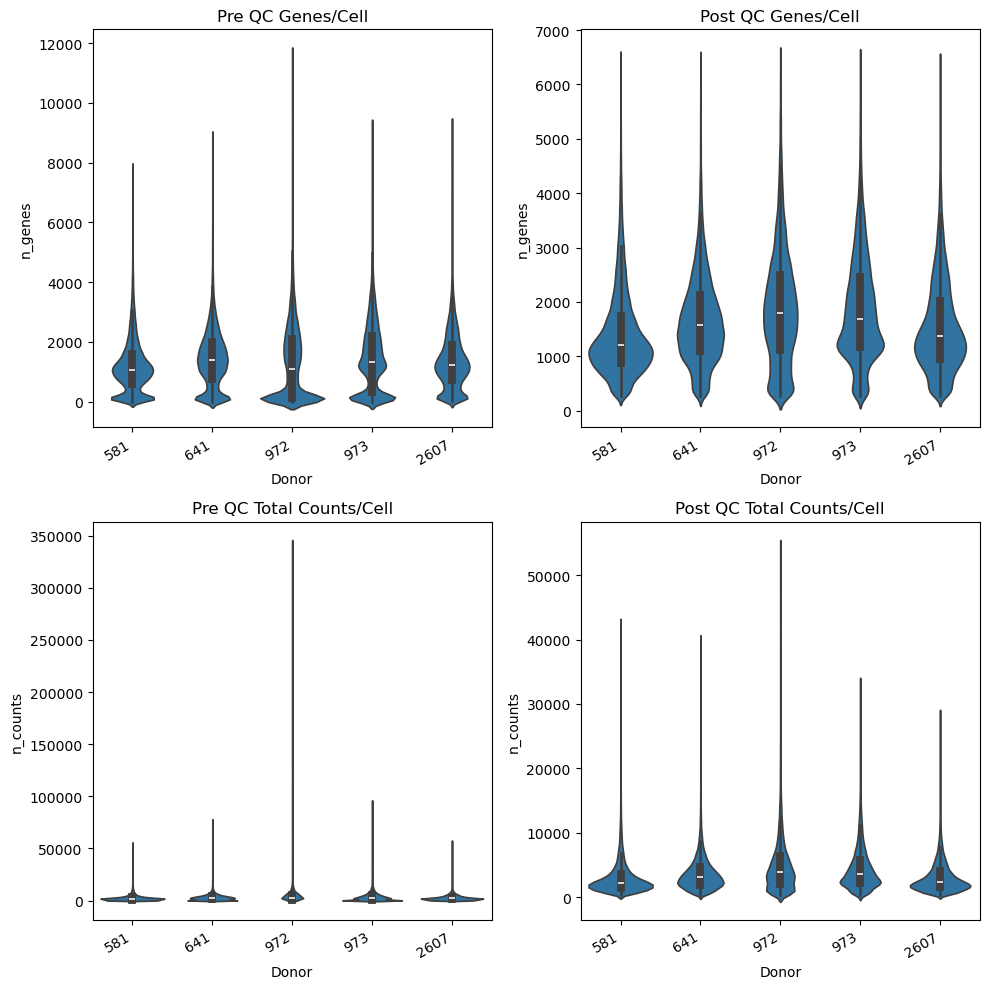

In [12]:
## Trialing QC Cutoffs Before and After ##

## Boolean Cutoffs for UMIs and Genes/Cell ##

counts_filter = (n_counts_lower < fernando_adata.obs.n_genes) & (fernando_adata.obs.n_genes < n_counts_upper)
genes_filter = (n_genes_lower < fernando_adata.obs.n_genes) & (fernando_adata.obs.n_genes < n_genes_upper)

# Plot Changes With Violins 

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()
sns.violinplot(data=fernando_adata.obs, y='n_genes', x='Donor', ax=axes[0])
axes[0].set_title('Pre QC Genes/Cell')
plt.setp(axes[0].get_xticklabels(), rotation=30, ha='right')

sns.violinplot(data=fernando_adata.obs[counts_filter & genes_filter], x='Donor', y='n_genes', ax=axes[1])
axes[1].set_title('Post QC Genes/Cell')
plt.setp(axes[1].get_xticklabels(), rotation=30, ha='right')

sns.violinplot(data=fernando_adata.obs, y='n_counts', x='Donor', ax=axes[2])
axes[2].set_title('Pre QC Total Counts/Cell')
plt.setp(axes[2].get_xticklabels(), rotation=30, ha='right')

sns.violinplot(data=fernando_adata.obs[fernando_adata.obs.passed_qc & genes_filter], x='Donor', y='n_counts', ax=axes[3])
axes[3].set_title('Post QC Total Counts/Cell')
plt.setp(axes[3].get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

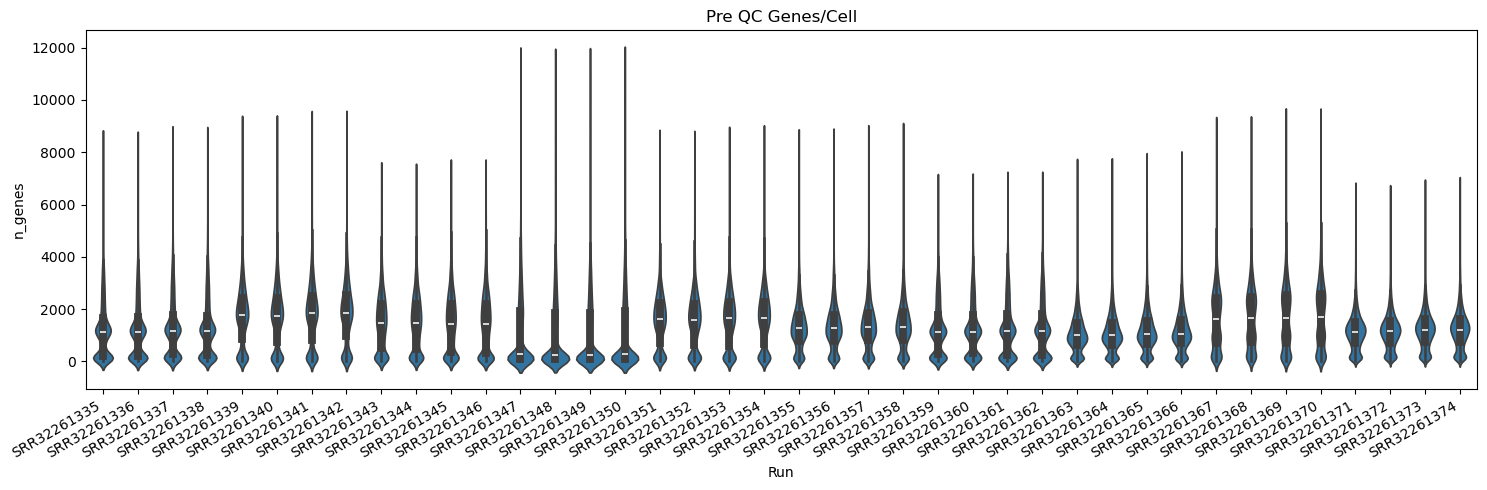

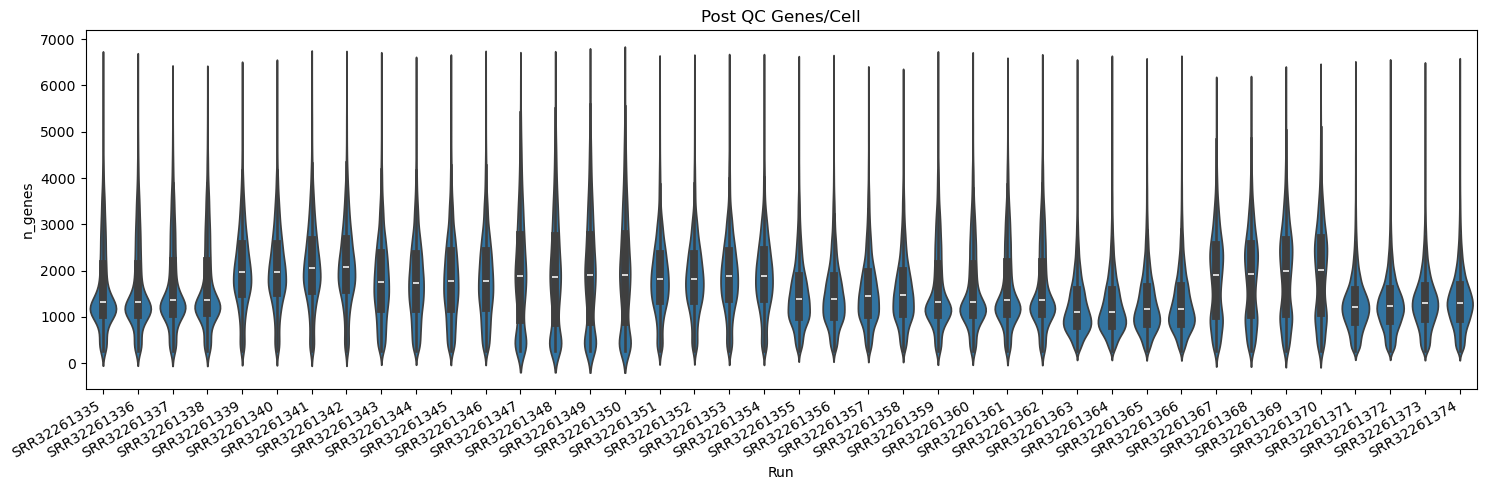

In [13]:
## Pre and Post QC Filtration By Library ##

plt.figure(figsize=(15,5))
plt.title('Pre QC Genes/Cell')
sns.violinplot(data=fernando_adata.obs, x='Run', y='n_genes')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(15,5))
plt.title('Post QC Genes/Cell')
sns.violinplot(data=fernando_adata.obs[counts_filter & genes_filter], x='Run', y='n_genes')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [14]:
fernando_adata.obs['passed_qc'].value_counts()

passed_qc
True    465228
Name: count, dtype: int64

In [15]:
# ## Remove Cells That Don't Meet Total Counts/Cell and Genes/Cell Thresholds ##

fernando_adata = MultimodalData(UnimodalData(fernando_adata, modality="rna"))

pg.qc_metrics(fernando_adata, 
              min_genes=n_genes_lower, max_genes=n_genes_upper,
              min_umis=n_counts_lower, max_umis=n_counts_upper,
              mito_prefix='MT-', percent_mito=10)

pg.filter_data(fernando_adata)
gc.collect()
fernando_adata = fernando_adata.to_anndata()

2026-02-22 22:50:05,034 - pegasusio.qc_utils - INFO - After filtration, 342481 out of 465228 cell barcodes are kept in UnimodalData object unknown-rna.
2026-02-22 22:50:05,035 - pegasus.tools.preprocessing - INFO - Function 'filter_data' finished in 0.89s.


In [16]:
## Filter Cells and Genes With Raw Cutoffs #

# store raw counts in layer
fernando_adata.layers["raw_counts"] = fernando_adata.X

# Note: No cells fail this cutoff affter using MAD based filtration
print((fernando_adata.obs.n_genes < 100).sum())
print((fernando_adata.var.n_cells < 20).any())

# Doing This For Completeness
sc.pp.filter_cells(fernando_adata, min_genes=100)
sc.pp.filter_genes(fernando_adata, min_cells=20)

0
False


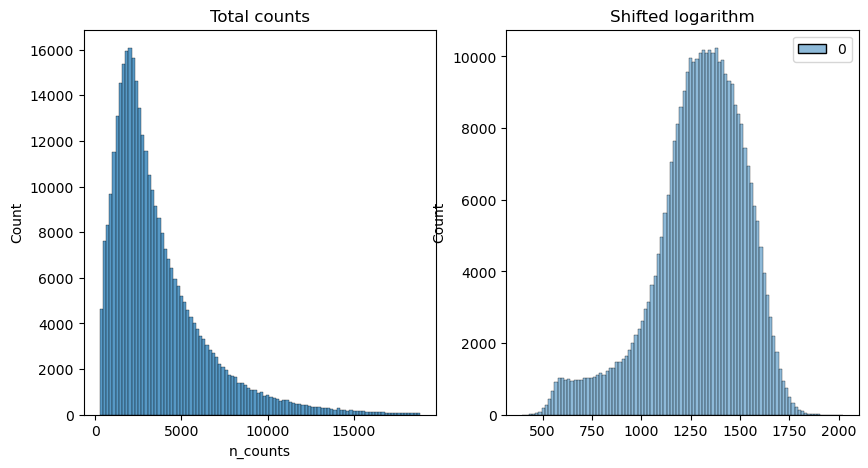

In [17]:
## Log Normalization ##

# normalize 
scales_counts = sc.pp.normalize_total(fernando_adata, layer='raw_counts', target_sum=None, inplace=False)

# log1p transform
fernando_adata.layers["log1p_norm"] = sc.pp.log1p(scales_counts["X"], copy=True)

# set X as log1p normed counts
fernando_adata.X = fernando_adata.layers["log1p_norm"]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
p1 = sns.histplot(fernando_adata.obs["n_counts"], bins=100, kde=False, ax=axes[0])
axes[0].set_title("Total counts")
p2 = sns.histplot(fernando_adata.layers["log1p_norm"].sum(1), bins=100, kde=False, ax=axes[1])
axes[1].set_title("Shifted logarithm")
plt.show()

2026-02-22 22:50:29,933 - pegasus.tools.utils - INFO - Loaded signatures from GMT file /home/deepak/pixi_envs/pegasus/.pixi/envs/default/lib/python3.10/site-packages/pegasus/data_files/cell_cycle_human.gmt.
2026-02-22 22:50:29,935 - pegasus.tools.signature_score - INFO - Signature G1/S: 43 out of 43 genes are used in signature score calculation.
2026-02-22 22:50:30,820 - pegasus.tools.signature_score - INFO - Signature G2/M: 54 out of 54 genes are used in signature score calculation.
2026-02-22 22:50:31,844 - pegasus.tools.signature_score - INFO - Function 'calc_signature_score' finished in 4.04s.
2026-02-22 22:51:11,843 - pegasus.tools.preprocessing - INFO - Function 'pca' finished in 13.78s.


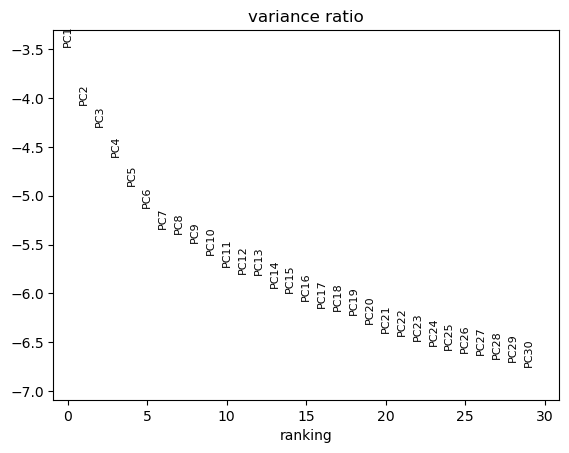

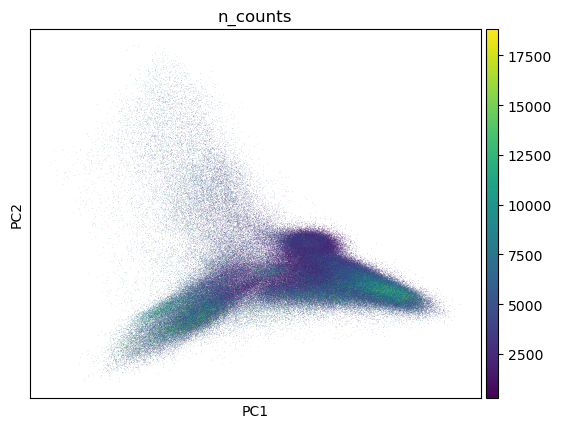

There is 14.103053245762206 variance explained by these components
2026-02-22 22:51:13,167 - pegasus.tools.preprocessing - INFO - Function 'regress_out' finished in 0.37s.
2026-02-22 22:51:13,171 - pegasus.tools.batch_correction - INFO - Start integration using Harmony.
	Initialization is completed.
	Completed 1 / 20 iteration(s).
	Completed 2 / 20 iteration(s).
	Completed 3 / 20 iteration(s).
	Completed 4 / 20 iteration(s).
	Completed 5 / 20 iteration(s).
	Completed 6 / 20 iteration(s).
	Completed 7 / 20 iteration(s).
	Completed 8 / 20 iteration(s).
Reach convergence after 8 iteration(s).
2026-02-22 22:52:18,310 - pegasus.tools.batch_correction - INFO - Function 'run_harmony' finished in 65.14s.
2026-02-22 22:53:00,434 - pegasus.tools.nearest_neighbors - INFO - Function 'get_neighbors' finished in 42.12s.
2026-02-22 22:53:05,868 - pegasus.tools.nearest_neighbors - INFO - Function 'calculate_affinity_matrix' finished in 5.43s.
2026-02-22 22:53:13,154 - pegasus.tools.graph_operations - 

/home/deepak/pixi_envs/pegasus/.pixi/envs/default/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Sun Feb 22 22:54:13 2026 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Sun Feb 22 22:56:26 2026 Finished embedding
2026-02-22 22:56:26,761 - pegasus.tools.visualization - INFO - Function 'umap' finished in 135.45s.


In [18]:
# Calculate Highly Variable Genes (not using deviance) ##

if not isinstance(fernando_adata, UnimodalData):
    fernando_adata = UnimodalData(fernando_adata)

## ROUND 0 ##

# calc score requires a float downcast for some reason
fernando_adata.X = fernando_adata.X.astype('float32')
pg.calc_signature_score(fernando_adata, 'cell_cycle_human')

# calculate HVGs on a protein_coding_autosomal only gene list
fernandao_hvg = fernando_adata[:,fernando_adata.var.robust_protein_coding_autosome].copy()
fernandao_hvg = fernandao_hvg.to_anndata()
hvg = sc.pp.highly_variable_genes(fernandao_hvg, layer='log1p_norm', n_top_genes=3000, inplace=False, subset=False)
hvg_list = fernandao_hvg.var.index[hvg.highly_variable].tolist()
del fernandao_hvg
gc.collect()

# apply that HVG list to your original anndata object
fernando_adata.var['highly_variable_features'] = False
fernando_adata.var['highly_variable_features'] = fernando_adata.var.index.isin(hvg_list)

## Dimensionality Reduction ##

# PCA

if not isinstance(fernando_adata, UnimodalData):
    fernando_adata = UnimodalData(fernando_adata)

pg.pca(fernando_adata, n_components=30)
sc.pl.pca_variance_ratio(fernando_adata, n_pcs=30, log=True)
sc.pl.pca_scatter(fernando_adata.to_anndata(), color="n_counts")
plt.show()

print('There is {0} variance explained by these components'.format(fernando_adata.uns['pca']['variance_ratio'].sum()*100))

# # Regress Out ##

pg.regress_out(fernando_adata, ['n_counts', 'percent_mito'])

## Harmony  

pg.run_harmony(fernando_adata, batch=['Donor'], rep='pca_regressed', max_iter_harmony=20, n_comps=30)

# # UMAP

pg.neighbors(fernando_adata, rep='pca_regressed_harmony', use_cache=False, dist='l2', K=100, n_comps=30)
pg.leiden(fernando_adata, rep='pca_regressed_harmony', resolution=0.1, class_label='class')
pg.umap(fernando_adata, rep='pca_regressed_harmony', n_neighbors=15, rep_ncomps=30)
plt.show()

fernando_adata = fernando_adata.to_anndata()

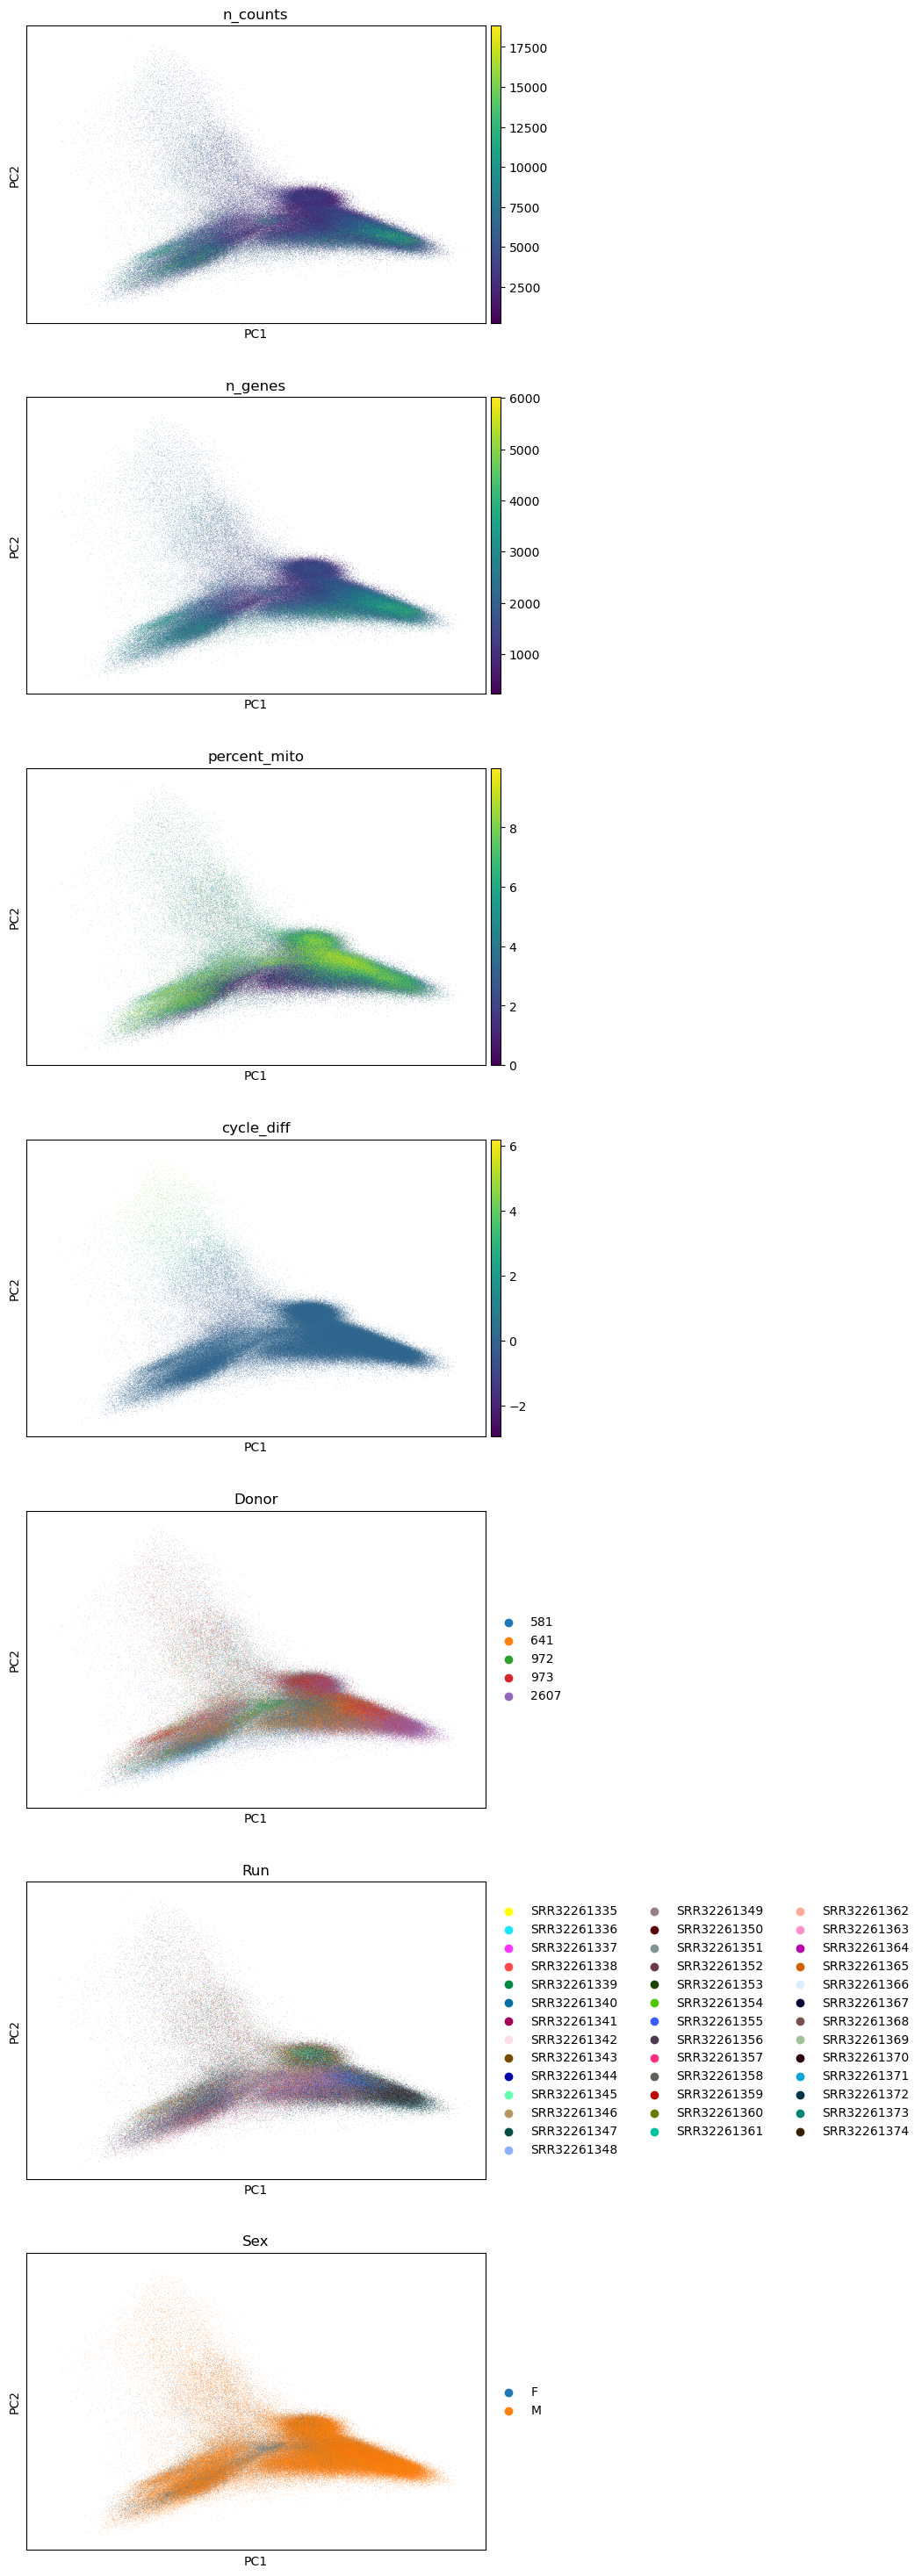

In [19]:
sc.pl.pca(fernando_adata, color=["n_counts", "n_genes", "percent_mito", 'cycle_diff', 'Donor', 'Run', 'Sex'], ncols=1)

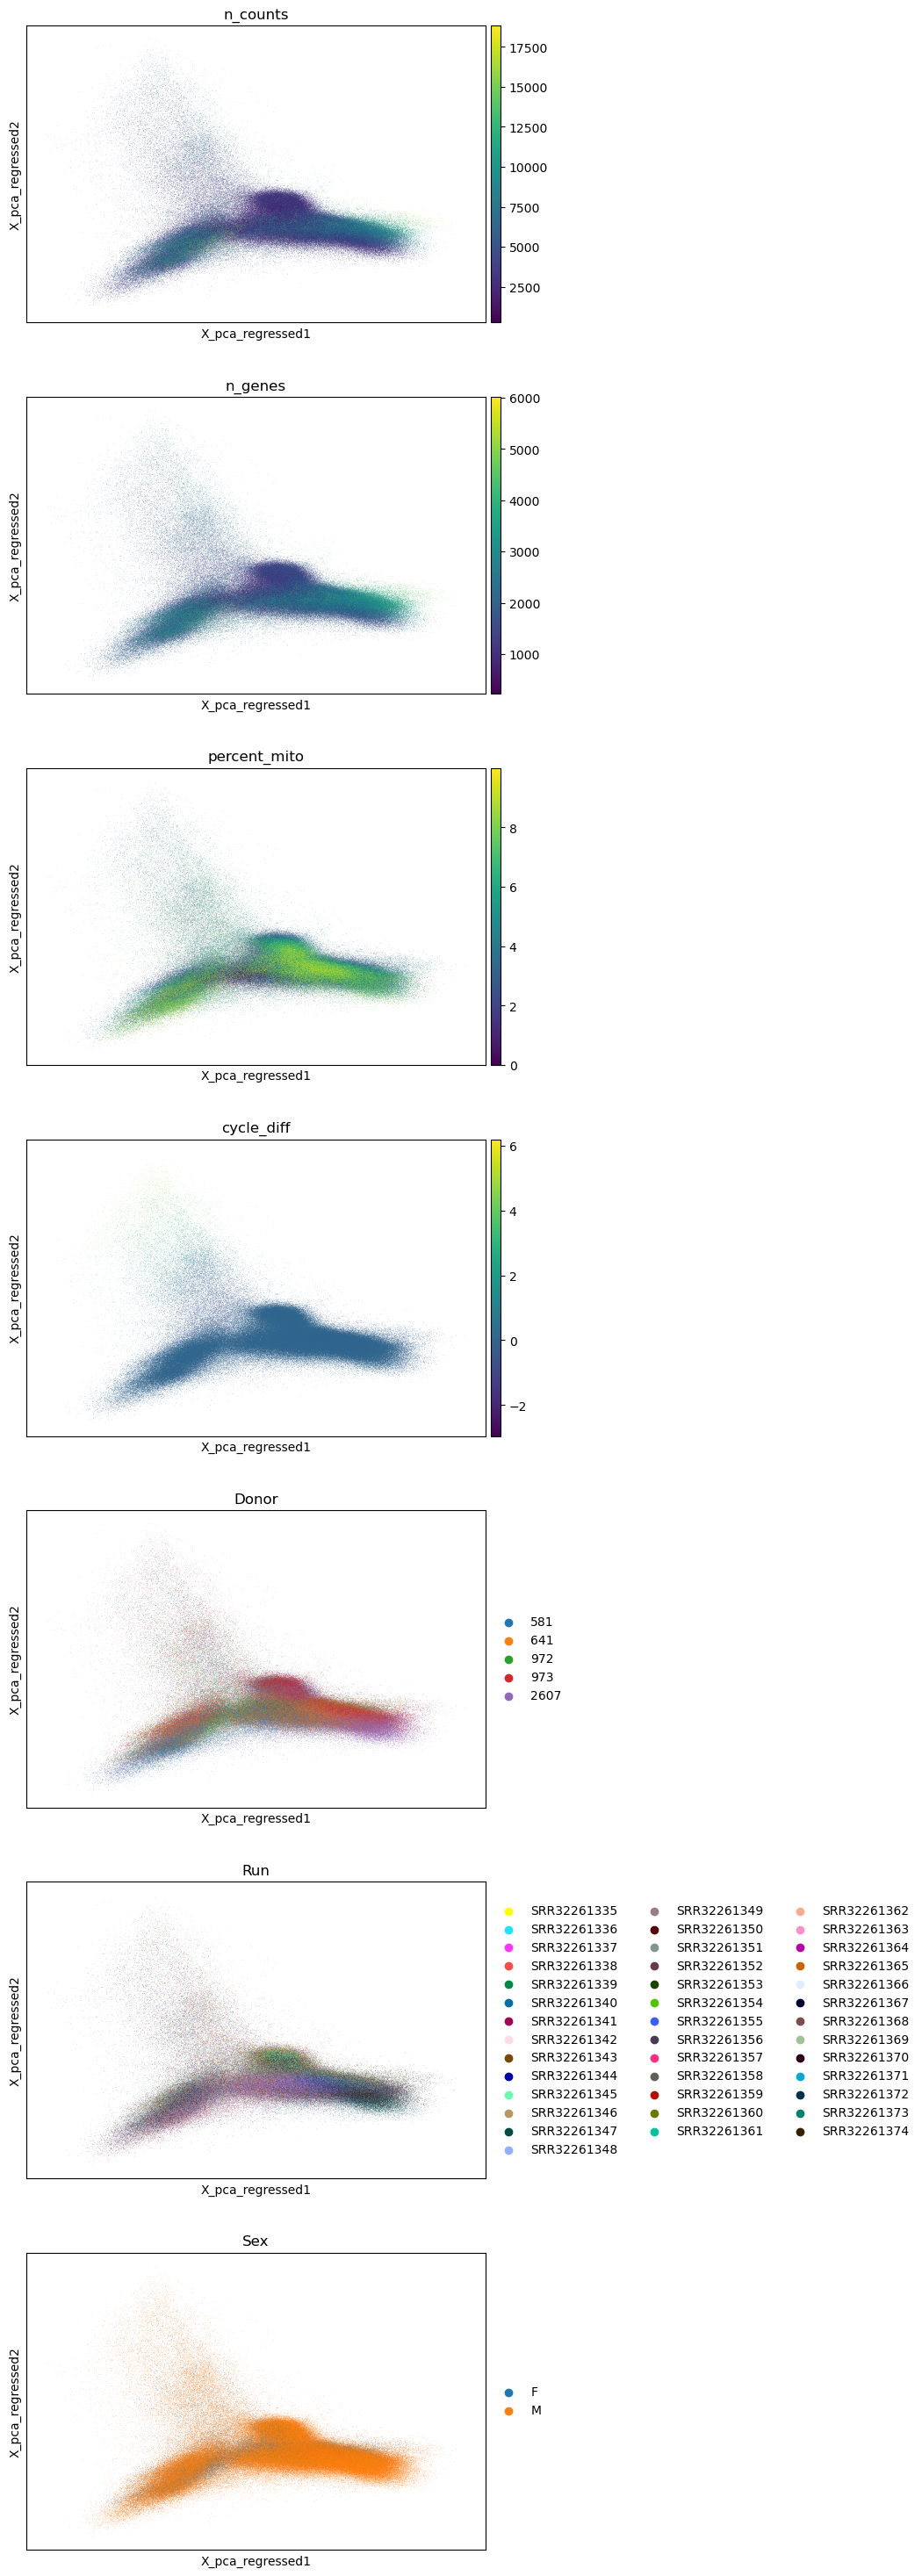

In [20]:
sc.pl.embedding(fernando_adata, basis='X_pca_regressed', 
                color=["n_counts", "n_genes", "percent_mito", 'cycle_diff', 'Donor', 'Run', 'Sex'], ncols=1)

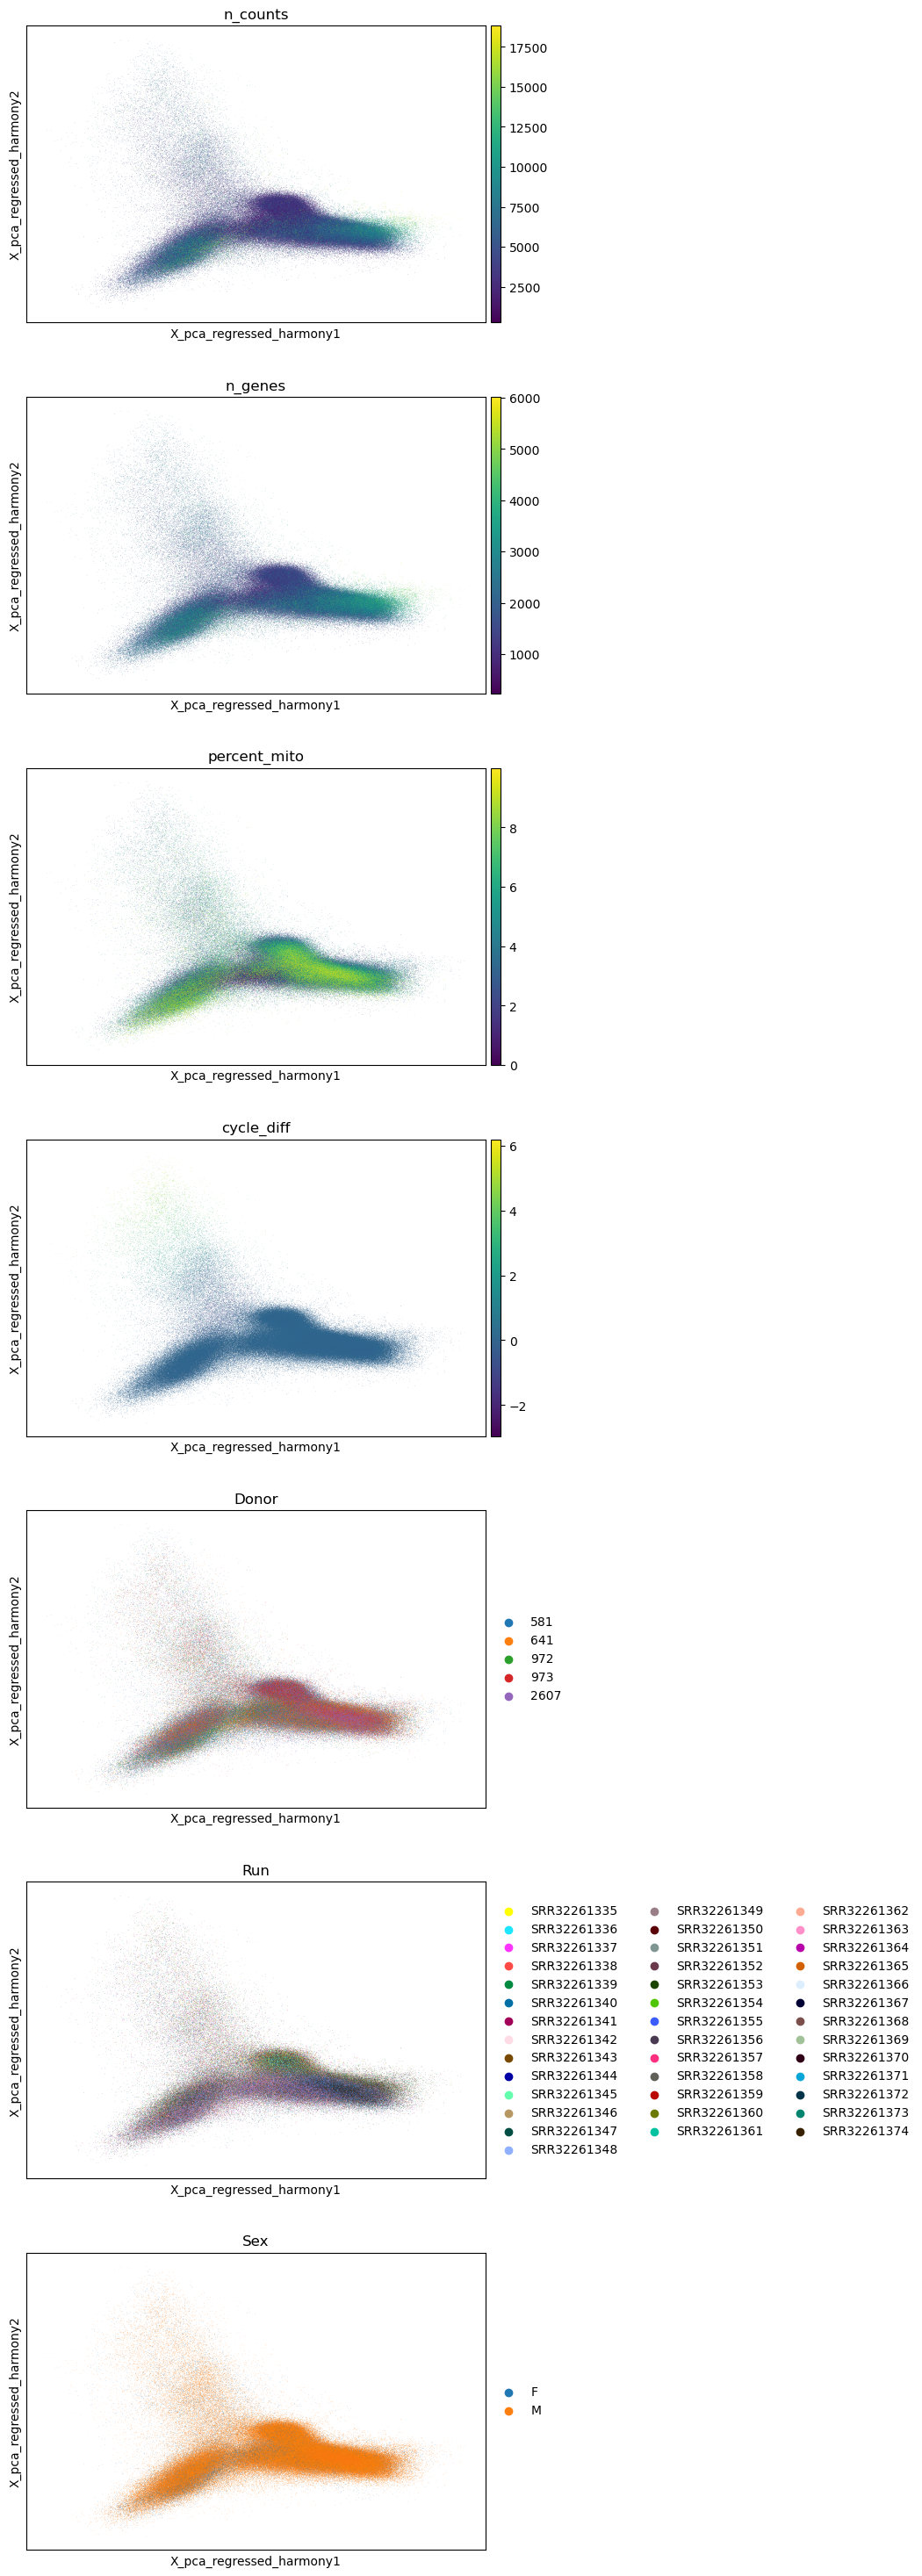

In [21]:
sc.pl.embedding(fernando_adata, basis='X_pca_regressed_harmony', 
                color=["n_counts", "n_genes", "percent_mito", 'cycle_diff', 'Donor', 'Run', 'Sex'], ncols=1)

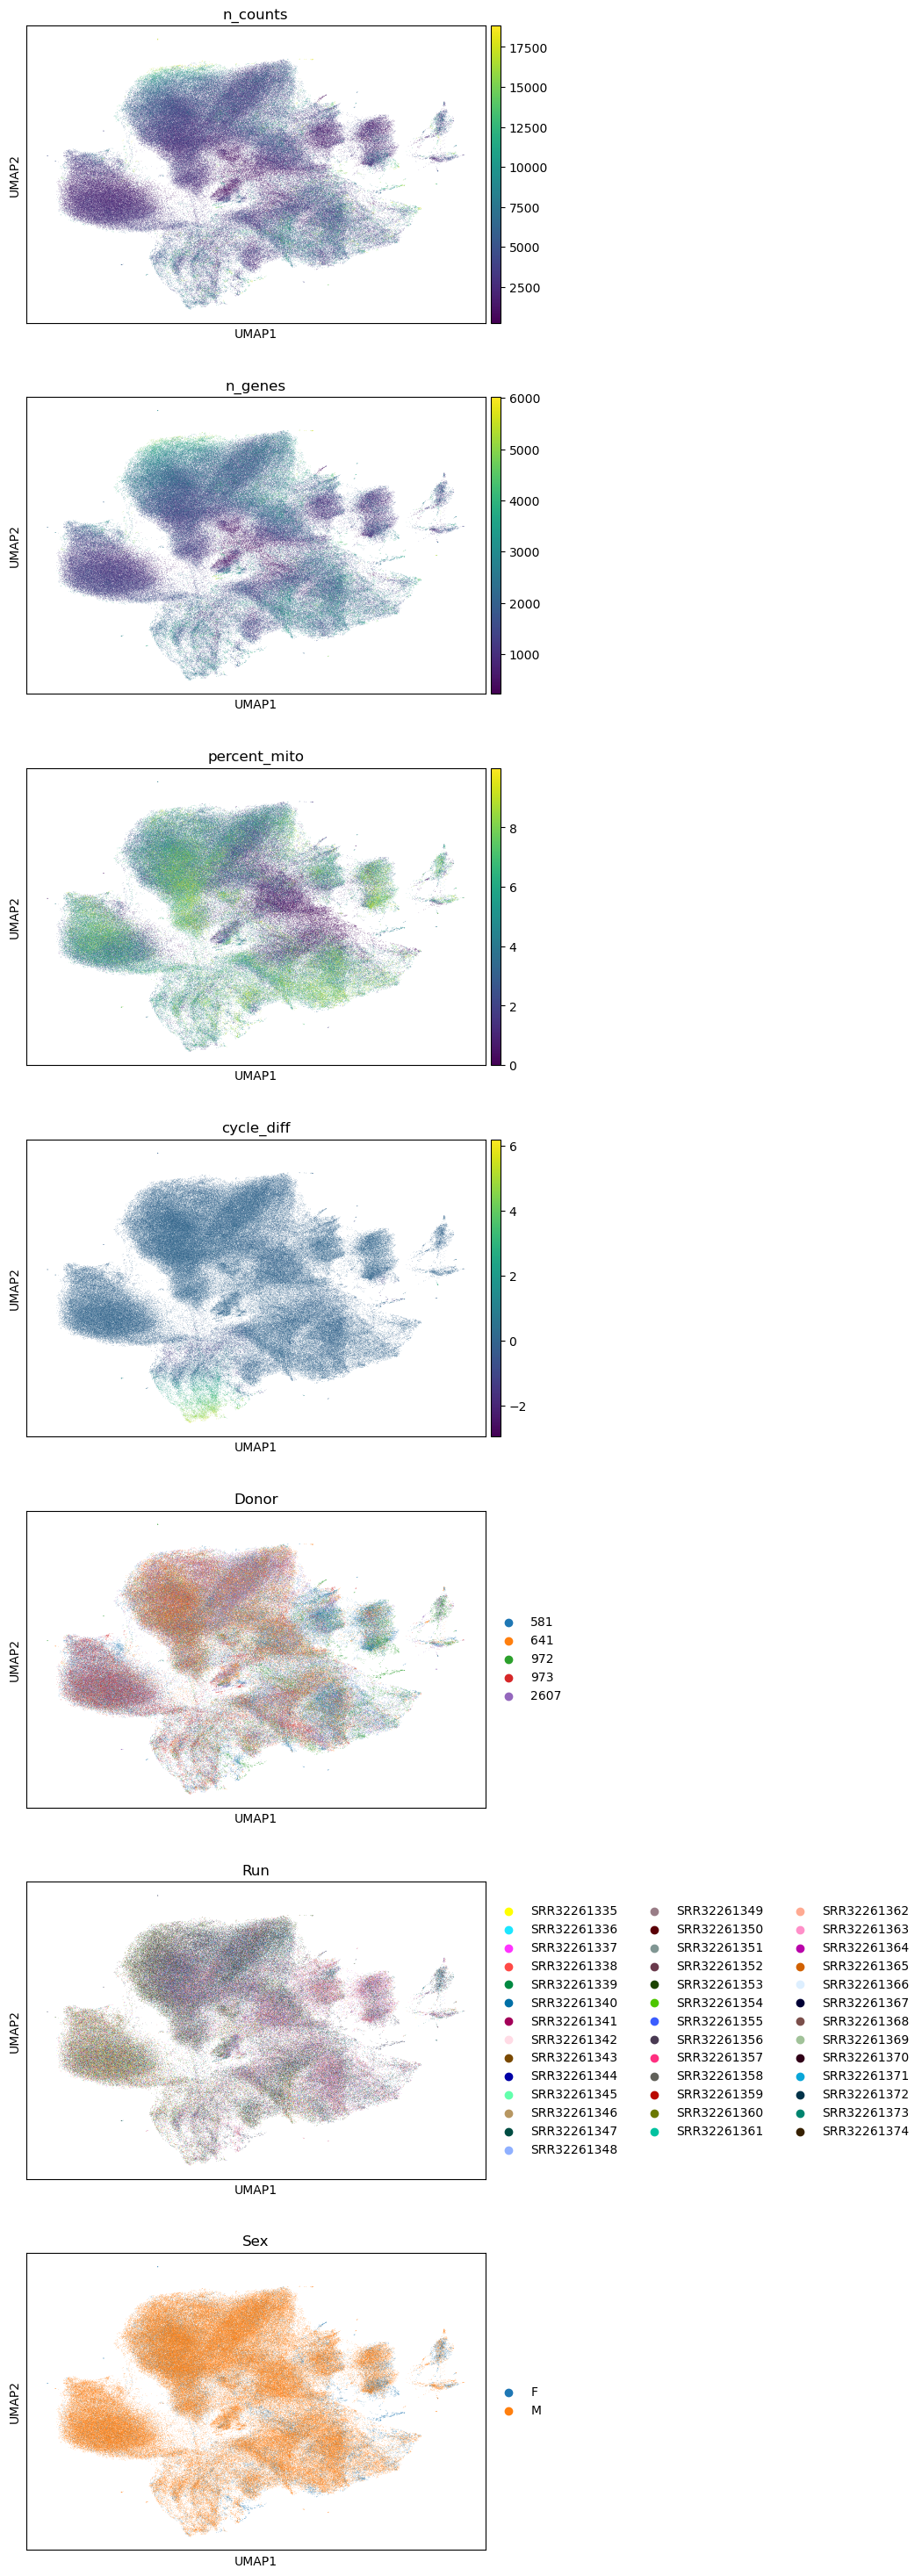

In [22]:
sc.pl.umap(fernando_adata, color=["n_counts", "n_genes", "percent_mito", 'cycle_diff', 'Donor', 'Run', 'Sex'], ncols=1)

In [23]:
## Align Key Columns Across Datasets ##

fernando_adata.obs['Day'] = 27 # (6 months * 4.5 weeks/month)
fernando_adata.obs.rename({'genotype':'Genotype'}, inplace=True, axis=1)
fernando_adata.obs['Manuscript'] = 'Fernando'
fernando_adata.obs['Protocol'] = 'Pasca (Sloan)'

In [24]:
## Cells After QC ##

fernando_adata.X.shape[0]

342481

In [25]:
## Save Step ##

fernando_adata.write_h5ad(os.path.join('/mnt/sdb/scz_meta_analysis_processed/fernando_brennand/anndata_objs/fernando_qc.h5ad'))

In [ ]:
sc.pl.umap(fernando_adata, color=['SOX2', 'PAX6', 'EOMES', 'NEUROD6', 'SLC17A7', 'DLX2'], ncols=2)